# pandas 시계열 데이터 처리

- 날짜형 변환
- DatetimeIndex
- resample / shift / rolling

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from datetime import datetime
plt.rcParams['figure.figsize'] = (10, 4)

In [18]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/05 판다스 넘파이 크롤링 실습/Day_04_file')
os.getcwd()

'/content/drive/MyDrive/Colab Notebooks/05 판다스 넘파이 크롤링 실습/Day_04_file'

## 1. datetime 기본 이해

### (1) datetime 오브젝트

In [3]:
now1 = datetime.now() # 현재 시간 1
print(now1)

2026-06-24 06:05:10.164360


In [5]:
now2 = datetime.today() # 현재 시간 2
print(now2)

2026-06-24 06:05:36.383410


In [9]:
t1 = datetime.now()
t2 = datetime(1970, 1, 1)
             # 년,  월, 일, 시, 분, 초
t3 = datetime(1970, 12, 12, 13, 24, 34)

print(t1)
print(t2)
print(t3)

2026-06-24 06:07:41.353449
1970-01-01 00:00:00
1970-12-12 13:24:34


### (2) datetime 오브젝트로 시간 계산하기

In [12]:
diff1 = t1 - t2  # 날짜 차이
print(diff1)

20628 days, 6:07:41.353449


In [13]:
type(diff1)

datetime.timedelta

In [14]:
diff2 = t2 - t1
print(diff2)

-20629 days, 17:52:18.646551


## 2. 문자열 날짜를 pandas 날짜형으로 변환하기

### (1) 문자열을 datetime 오브젝트로 변환하기

In [19]:
# 에볼라 바이러스 발병 데이터

ebola = pd.read_csv('country_timeseries.csv')

In [20]:
ebola.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
0,1/5/2015,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN
1,1/4/2015,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN
2,1/3/2015,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN
3,1/2/2015,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN
4,12/31/2014,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN


In [21]:
ebola.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    object 
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     flo

In [22]:
# 2-1-1

ebola['date_dt'] = pd.to_datetime(ebola['Date'])  # datetime 오브젝트를 이용해서 날짜 형식 수정

In [23]:
ebola.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali,date_dt
0,1/5/2015,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN,2015-01-05
1,1/4/2015,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN,2015-01-04
2,1/3/2015,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN,2015-01-03
3,1/2/2015,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN,2015-01-02
4,12/31/2014,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN,2014-12-31


In [24]:
ebola.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

In [26]:
# format: 원본 날짜 읽는 순서 지정
test_df1 = pd.DataFrame({'order_day': ['01/01/15', '02/01/15', '03/01/15']})
                                                                                # 주어진 값을 아래대로 읽게 설정함
test_df1['date_dt1'] = pd.to_datetime(test_df1['order_day'], format='%d/%m/%y') # 일/월/년
test_df1['date_dt2'] = pd.to_datetime(test_df1['order_day'], format='%m/%d/%y') # 월/일/년
test_df1['date_dt3'] = pd.to_datetime(test_df1['order_day'], format='%y/%m/%d') # 년/월/일
test_df1

,order_day,date_dt1,date_dt2,date_dt3
0,01/01/15,2015-01-01,2015-01-01,2001-01-15
1,02/01/15,2015-01-02,2015-02-01,2002-01-15
2,03/01/15,2015-01-03,2015-03-01,2003-01-15


In [27]:
# 구분자도 원본과 맞춤
test_df2 = pd.DataFrame({'order_day': ['01-01-15', '02-01-15', '03-01-15']})
test_df2['date_dt'] = pd.to_datetime(test_df2['order_day'], format='%d-%m-%y')
test_df2

,order_day,date_dt
0,01-01-15,2015-01-01
1,02-01-15,2015-01-02
2,03-01-15,2015-01-03


### (2) read_csv에서 날짜 컬럼 바로 변환하기

In [29]:
# CSV를 읽으면서 Date를 날짜형으로 변환
ebola1 = pd.read_csv('country_timeseries.csv', parse_dates=['Date'])
ebola1.head()

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone,Cases_Nigeria,Cases_Senegal,Cases_UnitedStates,Cases_Spain,Cases_Mali,Deaths_Guinea,Deaths_Liberia,Deaths_SierraLeone,Deaths_Nigeria,Deaths_Senegal,Deaths_UnitedStates,Deaths_Spain,Deaths_Mali
0,2015-01-05,289,2776.0,NaN,10030.0,NaN,NaN,NaN,NaN,NaN,1786.0,NaN,2977.0,NaN,NaN,NaN,NaN,NaN
1,2015-01-04,288,2775.0,NaN,9780.0,NaN,NaN,NaN,NaN,NaN,1781.0,NaN,2943.0,NaN,NaN,NaN,NaN,NaN
2,2015-01-03,287,2769.0,8166.0,9722.0,NaN,NaN,NaN,NaN,NaN,1767.0,3496.0,2915.0,NaN,NaN,NaN,NaN,NaN
3,2015-01-02,286,NaN,8157.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3496.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-31,284,2730.0,8115.0,9633.0,NaN,NaN,NaN,NaN,NaN,1739.0,3471.0,2827.0,NaN,NaN,NaN,NaN,NaN


In [30]:
ebola1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    datetime64[ns]
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

## 3. 날짜 정보 추출하기
### (1) datetime 오브젝트에서 날짜 정보 추출하기

In [31]:
# 문자열 Series → 날짜형 Series
date_series = pd.Series(['2018-05-16', '2018-05-17', '2018-05-18'])
d1 = pd.to_datetime(date_series)
d1

,0
0,2018-05-16
1,2018-05-17
2,2018-05-18


In [32]:
d1[0] # 한번에 처리할 수는 없음

Timestamp('2018-05-16 00:00:00')

In [33]:
d1[0].year

2018

In [34]:
d1[0].month

5

In [35]:
d1[0].day

16

### (2) dt 접근자 사용하기

In [49]:
# Date 컬럼을 날짜형으로 변환
ebola = pd.read_csv('country_timeseries.csv')
ebola['date_dt'] = pd.to_datetime(ebola['Date']) # 2-1-1 에서도 date_dt 사용
ebola[['Date', 'date_dt']].head()


,Date,date_dt
0,1/5/2015,2015-01-05
1,1/4/2015,2015-01-04
2,1/3/2015,2015-01-03
3,1/2/2015,2015-01-02
4,12/31/2014,2014-12-31


In [50]:
ebola['date_dt'][3]

Timestamp('2015-01-02 00:00:00')

In [38]:
ebola['date_dt'][3].year

2015

In [39]:
ebola['date_dt'][3].month

1

In [40]:
ebola['date_dt'][3].day

2

In [41]:
# 연도 추출
ebola['year'] = ebola['date_dt'].dt.year  # 별도의 속성값 생성 및 적용
ebola[['Date', 'date_dt', 'year']].head() # 확인

,Date,date_dt,year
0,1/5/2015,2015-01-05,2015
1,1/4/2015,2015-01-04,2015
2,1/3/2015,2015-01-03,2015
3,1/2/2015,2015-01-02,2015
4,12/31/2014,2014-12-31,2014


In [42]:
# 월/일 추출
ebola['month'], ebola['day'] = (ebola['date_dt'].dt.month, ebola['date_dt'].dt.day) # 별도의 속성값 생성 및 적용
ebola[['Date', 'date_dt', 'year', 'month', 'day']].head()                           # 확인

,Date,date_dt,year,month,day
0,1/5/2015,2015-01-05,2015,1,5
1,1/4/2015,2015-01-04,2015,1,4
2,1/3/2015,2015-01-03,2015,1,3
3,1/2/2015,2015-01-02,2015,1,2
4,12/31/2014,2014-12-31,2014,12,31


In [43]:
ebola.info() # 늘어남

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

### (3) 최초 발병일 기준으로 경과일 계산하기

In [44]:
# 마지막 5행, 앞쪽 5열
ebola.iloc[-5:, :5]       # 필요한 것(최초 발병일 확인)

,Date,Day,Cases_Guinea,Cases_Liberia,Cases_SierraLeone
117,3/27/2014,5,103.0,8.0,6.0
118,3/26/2014,4,86.0,NaN,NaN
119,3/25/2014,3,86.0,NaN,NaN
120,3/24/2014,2,86.0,NaN,NaN
121,3/22/2014,0,49.0,NaN,NaN


In [45]:
# 가장 이른 날짜
ebola['date_dt'].min()       # min = 시작일

Timestamp('2014-03-22 00:00:00')

In [46]:
type(ebola['date_dt'].min()) # 데이터 타입이 뭔지 확인(dt 적용하기 위해 확인차)

pandas._libs.tslibs.timestamps.Timestamp

In [47]:
# 최초 날짜 기준 경과 시간
ebola['outbreak_d'] = ebola['date_dt'] - ebola['date_dt'].min()
ebola[['Date', 'Day', 'outbreak_d']].head()

,Date,Day,outbreak_d
0,1/5/2015,289,289 days
1,1/4/2015,288,288 days
2,1/3/2015,287,287 days
3,1/2/2015,286,286 days
4,12/31/2014,284,284 days


## 4. 은행 파산 데이터로 연도/분기 집계하기

### (1) 파산 은행 수 집계

In [51]:
banks_no_dates = pd.read_csv('banklist.csv')
banks_no_dates.head()

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",26-May-17,26-Jul-17
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,5-May-17,26-Jul-17
2,First NBC Bank,New Orleans,LA,58302,Whitney Bank,28-Apr-17,26-Jul-17
3,Proficio Bank,Cottonwood Heights,UT,35495,Cache Valley Bank,3-Mar-17,18-May-17
4,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,27-Jan-17,18-May-17


In [52]:
banks_no_dates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              553 non-null    object
 1   City                   553 non-null    object
 2   ST                     553 non-null    object
 3   CERT                   553 non-null    int64 
 4   Acquiring Institution  553 non-null    object
 5   Closing Date           553 non-null    object
 6   Updated Date           553 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.4+ KB


In [66]:
# 날짜 컬럼을 읽으면서 변환
banks = pd.read_csv('banklist.csv', parse_dates=['Closing Date', 'Updated Date'],date_format='%d-%b-%y') # Datetime으로 타입 변환 # %b : Apr 등 축약어 # %m : 숫자표기
banks.head()

,Bank Name,City,ST,CERT,Acquiring Institution,Closing Date,Updated Date
0,Fayette County Bank,Saint Elmo,IL,1802,"United Fidelity Bank, fsb",2017-05-26,2017-07-26
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",Milwaukee,WI,30003,First-Citizens Bank & Trust Company,2017-05-05,2017-07-26
2,First NBC Bank,New Orleans,LA,58302,Whitney Bank,2017-04-28,2017-07-26
3,Proficio Bank,Cottonwood Heights,UT,35495,Cache Valley Bank,2017-03-03,2017-05-18
4,Seaway Bank and Trust Company,Chicago,IL,19328,State Bank of Texas,2017-01-27,2017-05-18


In [54]:
banks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              553 non-null    object        
 1   City                   553 non-null    object        
 2   ST                     553 non-null    object        
 3   CERT                   553 non-null    int64         
 4   Acquiring Institution  553 non-null    object        
 5   Closing Date           553 non-null    datetime64[ns]
 6   Updated Date           553 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 30.4+ KB


In [67]:
# 분기/연도 컬럼 추가
banks['closing_quarter'], banks['closing_year'] = (
    banks['Closing Date'].dt.quarter,
    banks['Closing Date'].dt.year
)
banks[['Bank Name', 'Closing Date', 'closing_quarter', 'closing_year']].head()

,Bank Name,Closing Date,closing_quarter,closing_year
0,Fayette County Bank,2017-05-26,2,2017
1,"Guaranty Bank, (d/b/a BestBank in Georgia & Mi...",2017-05-05,2,2017
2,First NBC Bank,2017-04-28,2,2017
3,Proficio Bank,2017-03-03,1,2017
4,Seaway Bank and Trust Company,2017-01-27,1,2017


In [71]:
# 연도별 건수
closing_year = banks.groupby(['closing_year']).size() # 기준 묶고, 몇개인지 계산
closing_year

,0
closing_year,
2000,2
2001,4
2002,11
2003,3
2004,4
2007,3
2008,25
2009,140
2010,157


In [70]:
# 연도+분기별 건수
closing_year_q = banks.groupby(['closing_year', 'closing_quarter']).size() # 기준을 구별하여 계산
closing_year_q.head()

closing_year  closing_quarter
2000          4                  2
2001          1                  1
              2                  1
              3                  2
2002          1                  6
dtype: int64

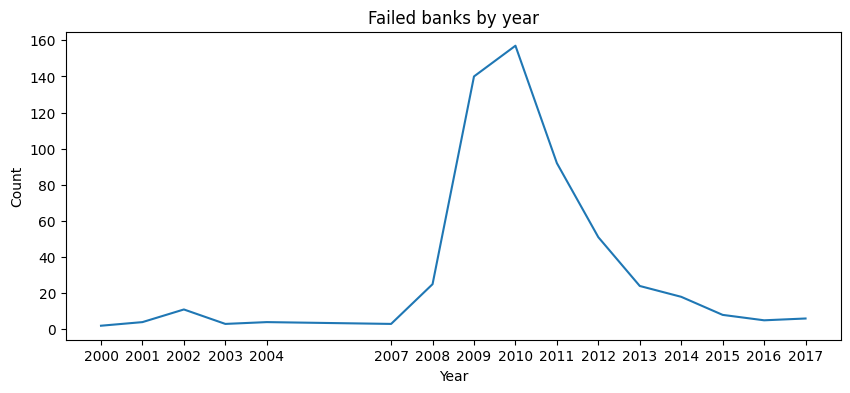

In [76]:
# 연도별 파산 은행 수 그래프
closing_year.plot(title='Failed banks by year')
plt.xticks(closing_year.index)
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

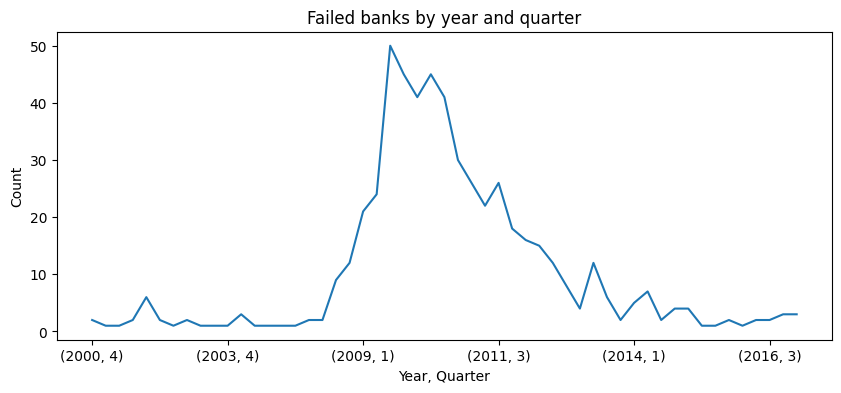

In [78]:
# 분기별 파산 은행 수 그래프
closing_year_q.plot(title='Failed banks by year and quarter')
plt.xlabel('Year, Quarter')
plt.ylabel('Count')
plt.show()

## 5. 주식 데이터에서 날짜 인덱스 사용하기

### (1) yfinance로 테슬라 주가 데이터 가져오기

- TSLA 주가 다운로드
- CSV 저장
- Date 컬럼을 시계열 기준으로 사용

In [79]:
# yfinance 설치
%pip install yfinance

In [101]:
# TSLA 주가 다운로드 후 CSV 저장
import yfinance as yf

tesla = yf.download(         # 전처리
    'TSLA',
    start='2010-01-01',
    end='2017-12-31',
    auto_adjust=False,
    progress=False,
    multi_level_index=False  # 전처리
)

print(tesla.head())          # 기본적으로 DATE 가 인덱스임
tesla = tesla.reset_index()  # 그걸 초기화 해줌
tesla

            Adj Close     Close      High       Low      Open     Volume
Date                                                                    
2010-06-29   1.592667  1.592667  1.666667  1.169333  1.266667  281494500
2010-06-30   1.588667  1.588667  2.028000  1.553333  1.719333  257806500
2010-07-01   1.464000  1.464000  1.728000  1.351333  1.666667  123282000
2010-07-02   1.280000  1.280000  1.540000  1.247333  1.533333   77097000
2010-07-06   1.074000  1.074000  1.333333  1.055333  1.333333  103003500


,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500
...,...,...,...,...,...,...,...
1886,2017-12-22,21.680000,21.680000,22.061333,21.654667,21.967333,63237000
1887,2017-12-26,21.152666,21.152666,21.596001,21.105333,21.588667,65676000
1888,2017-12-27,20.775999,20.775999,21.178667,20.716667,21.066668,70681500
1889,2017-12-28,21.024000,21.024000,21.054667,20.636000,20.783333,64744500


In [102]:
tesla.info()              # Date 가 Datetime으로 되어있음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891 entries, 0 to 1890
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1891 non-null   datetime64[ns]
 1   Adj Close  1891 non-null   float64       
 2   Close      1891 non-null   float64       
 3   High       1891 non-null   float64       
 4   Low        1891 non-null   float64       
 5   Open       1891 non-null   float64       
 6   Volume     1891 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 103.5 KB


In [103]:
# 2010년 6월만 필터링
tesla_2010_06 = tesla[(tesla['Date'].dt.year == 2010) & (tesla['Date'].dt.month == 6)]
tesla_2010_06.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500


In [104]:
# Date를 인덱스로 설정
tesla = tesla.set_index('Date')
tesla.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500


In [99]:
tesla.index

RangeIndex(start=0, stop=1891, step=1)

In [105]:
# 연도 문자열로 조회
tesla.loc['2015'].iloc[:5, :5]

,Adj Close,Close,High,Low,Open
Date,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333


In [106]:
# 연-월 문자열로 조회
tesla.loc['2010-06'].iloc[:, :5]

,Adj Close,Close,High,Low,Open
Date,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333


In [107]:
# 시작일 기준 경과 시간
tesla['ref_date'] = tesla.index - tesla.index.min()
tesla.iloc[:5, :5]

,Adj Close,Close,High,Low,Open
Date,,,,,
2010-06-29,1.592667,1.592667,1.666667,1.169333,1.266667
2010-06-30,1.588667,1.588667,2.028000,1.553333,1.719333
2010-07-01,1.464000,1.464000,1.728000,1.351333,1.666667
2010-07-02,1.280000,1.280000,1.540000,1.247333,1.533333
2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333


In [110]:
# ref_date 인덱스
tesla_ref = tesla.reset_index().set_index('ref_date')
tesla_ref.iloc[:5, :5]

,Date,Adj Close,Close,High,Low
ref_date,,,,,
0 days,2010-06-29,1.592667,1.592667,1.666667,1.169333
1 days,2010-06-30,1.588667,1.588667,2.028000,1.553333
2 days,2010-07-01,1.464000,1.464000,1.728000,1.351333
3 days,2010-07-02,1.280000,1.280000,1.540000,1.247333
7 days,2010-07-06,1.074000,1.074000,1.333333,1.055333


In [89]:
# 기간 문자열로 조회
tesla_ref.loc['5 days':].head()

,Date,Adj Close,Close,High,Low,Open,Volume
ref_date,,,,,,,
7 days,2010-07-06,1.074000,1.074000,1.333333,1.055333,1.333333,103003500
8 days,2010-07-07,1.053333,1.053333,1.108667,0.998667,1.093333,103825500
9 days,2010-07-08,1.164000,1.164000,1.168000,1.038000,1.076000,115671000
10 days,2010-07-09,1.160000,1.160000,1.193333,1.103333,1.172000,60759000
13 days,2010-07-12,1.136667,1.136667,1.204667,1.133333,1.196667,33037500
